In [2]:
import pandas as pd

url = "https://gist.githubusercontent.com/jwalsh/ce1dc0436aba5b7a5c9666f47fa5a380/raw/5ce3854392b43ff97907112d344fc008229b0445/titanic.csv"
df = pd.read_csv(url)
# df = pd.read_csv("data/train.csv")
print(df.head())
print(df.info())

   PassengerId  Survived  Pclass      Lname  \
0            1         0       3     Braund   
1            2         1       1    Cumings   
2            3         1       3  Heikkinen   
3            4         1       1   Futrelle   
4            5         0       3      Allen   

                                          Name     Sex   Age  SibSp  Parch  \
0                              Mr. Owen Harris    male  22.0      1      0   
1   Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0   
2                                  Miss. Laina  female  26.0      0      0   
3           Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0   
4                            Mr. William Henry    male  35.0      0      0   

             Ticket     Fare Cabin Embarked  
0         A/5 21171   7.2500   NaN        S  
1          PC 17599  71.2833   C85        C  
2  STON/O2. 3101282   7.9250   NaN        S  
3            113803  53.1000  C123        S  
4            37345

In [3]:
print(df.isnull().sum().sort_values(ascending=False))

Cabin          125
Age             30
Embarked         1
PassengerId      0
Survived         0
Pclass           0
Lname            0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [5]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [9]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [10]:
print(df.isnull().sum().sort_values(ascending=False))

Cabin          125
PassengerId      0
Survived         0
Pclass           0
Lname            0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64


In [11]:
drop_cols = ["PassengerId", "Name", "Lname", "Ticket", "Cabin"]
df = df.drop(columns=drop_cols)
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
df_encoded = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


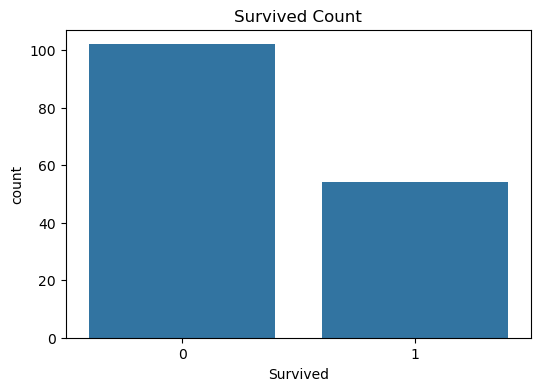

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survived Count")
plt.show()


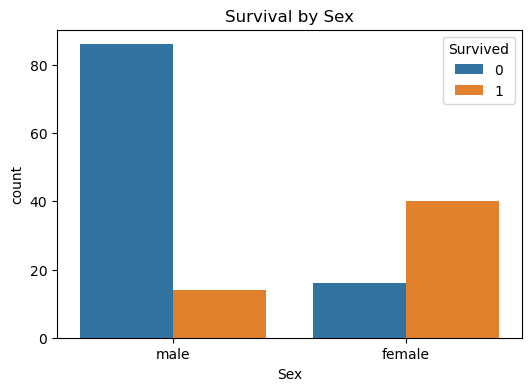

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()


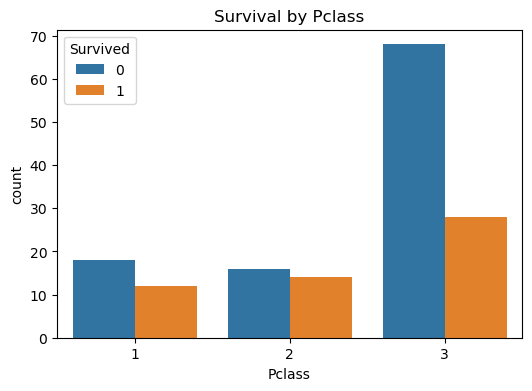

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Pclass")
plt.show()


In [16]:
df["Survived"].mean()

np.float64(0.34615384615384615)

In [17]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.714286
male      0.140000
Name: Survived, dtype: float64

In [18]:
df.groupby("Pclass")["Survived"].mean()


Pclass
1    0.400000
2    0.466667
3    0.291667
Name: Survived, dtype: float64

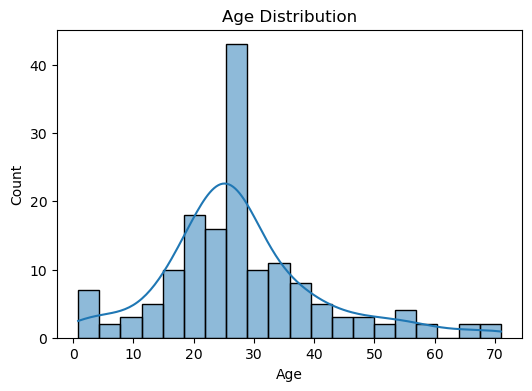

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


In [20]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child","Teen","Young","Adult","Senior"])
df.groupby("AgeGroup")["Survived"].mean()


C:\Users\PC2301\AppData\Local\Temp\ipykernel_32172\2297707551.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


AgeGroup
Child     0.384615
Teen      0.357143
Young     0.387755
Adult     0.222222
Senior    0.000000
Name: Survived, dtype: float64

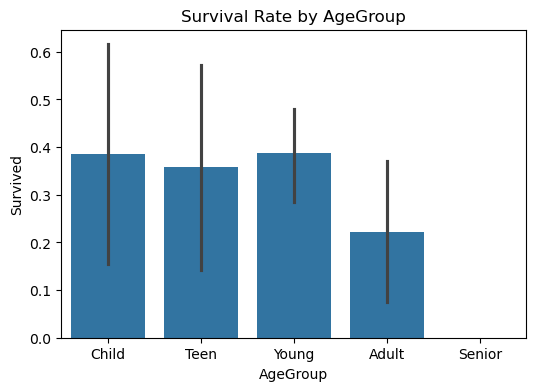

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival Rate by AgeGroup")
plt.show()


In [22]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["Survived"])
y = df_encoded["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
#print(X_train)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
 = scaler.fit_transform(X_test)

In [25]:
print(X_test_scaled)

[[ 0.70894901 -0.57170817 -0.55513611 -0.45056356 -0.42616997  0.82717019
  -0.25819889  0.52915026]
 [-0.62554324 -0.67344126  0.71374643  1.1514402   0.05530521  0.82717019
  -0.25819889  0.52915026]
 [ 0.70894901 -0.46997508 -0.55513611 -0.45056356 -0.42499027  0.82717019
  -0.25819889  0.52915026]
 [ 0.70894901 -0.46997508 -0.55513611 -0.45056356 -0.42957245 -1.20894105
  -0.25819889  0.52915026]
 [-0.62554324 -1.18210671  0.71374643 -0.45056356 -0.05598671 -1.20894105
  -0.25819889 -1.88982237]
 [ 0.70894901 -0.46997508 -0.55513611 -0.45056356 -0.42707308  0.82717019
  -0.25819889  0.52915026]
 [-1.96003549 -0.16477581 -0.55513611  1.1514402   3.56726577  0.82717019
  -0.25819889 -1.88982237]
 [ 0.70894901  0.03869037 -0.55513611 -0.45056356 -0.42547681  0.82717019
  -0.25819889  0.52915026]
 [ 0.70894901  0.03869037 -0.55513611 -0.45056356 -0.42547681  0.82717019
  -0.25819889 -1.88982237]
 [-0.62554324  0.85255508 -0.55513611  1.1514402  -0.17380365 -1.20894105
  -0.25819889  0.

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred))


Accuracy: 0.65625
Confusion Matrix:
 [[21  0]
 [11  0]]

Report:
               precision    recall  f1-score   support

           0       0.66      1.00      0.79        21
           1       0.00      0.00      0.00        11

    accuracy                           0.66        32
   macro avg       0.33      0.50      0.40        32
weighted avg       0.43      0.66      0.52        32



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with

In [34]:
# 승객 데이터 정규화 후 예측 실행
import pandas as pd

new_passenger = pd.DataFrame([{
    "Pclass": 3,
    "Age": 22,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 7.25,
    "Sex_male": 1,        # 남성
    "Embarked_Q": 0,
    "Embarked_S": 1       # S라고 가정
}])

In [31]:
X.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [33]:
#기존 X와 컬럼 순서 맞추기
new_passenger = new_passenger[X.columns]
#new_student = new_student[X.columns]

#정규화(scaler)
new_passenger_scaled = scaler.transform(new_passenger)

result = model.predict(new_passenger_scaled)
print(result)

TypeError: unhashable type: 'Index'